# 🦠 Analyse des Corona-Einflusses auf die Leichtathletik

Basierend auf der statistischen Voranalyse wissen wir, dass IAAF-Scores oft **nicht normalverteilt** sind. Daher nutzen wir robuste Metriken (Median, IQR, Mann-Whitney U) und visualisieren die Daten rein mit Matplotlib (ohne Seaborn).

## Ziele
1.  **Globaler Leistungstrend:** Median & IQR über die Jahre.
2.  **Teilnehmer-Einbruch:** Balkendiagramm & Heatmap der monatlichen Aktivität.
3.  **Verteilungs-Check:** Boxplots (2019 vs. 2020).
4.  **Statistik:** Signifikanztests.

In [2]:
import pandas as pd
import numpy as np
import sys
import os
from scipy import stats

# Add project root to path
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import util
import plotting.plotting_style as plt
from plotting.plotting_style import rgb

# Load Data
# file_path = '../../data_csv/final_Data_iaaf_scores_neu.csv'
df = util.load_data()

# Parse Dates
def parse_german_date(row):
    date_str = row['datum']
    year_col = row['jahr']
    
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    try:
        return pd.to_datetime(date_str, format='%d.%m.%Y')
    except ValueError:
        pass
    try:
        clean_str = date_str.rstrip('.')
        temp_date = pd.to_datetime(clean_str, format='%d.%m')
        return temp_date.replace(year=int(year_col))
    except ValueError:
        return pd.NaT

print("Parsing dates...")
df['parsed_date'] = df.apply(parse_german_date, axis=1)
df['month'] = df['parsed_date'].dt.month
df['day_of_year'] = df['parsed_date'].dt.dayofyear

df_recent = df[df['jahr'] >= 2016].copy()
print(f"Daten geladen: {len(df_recent)} Einträge.")

Parsing dates...
Daten geladen: 67189 Einträge.


## 1. Globaler Leistungstrend (Median & IQR)

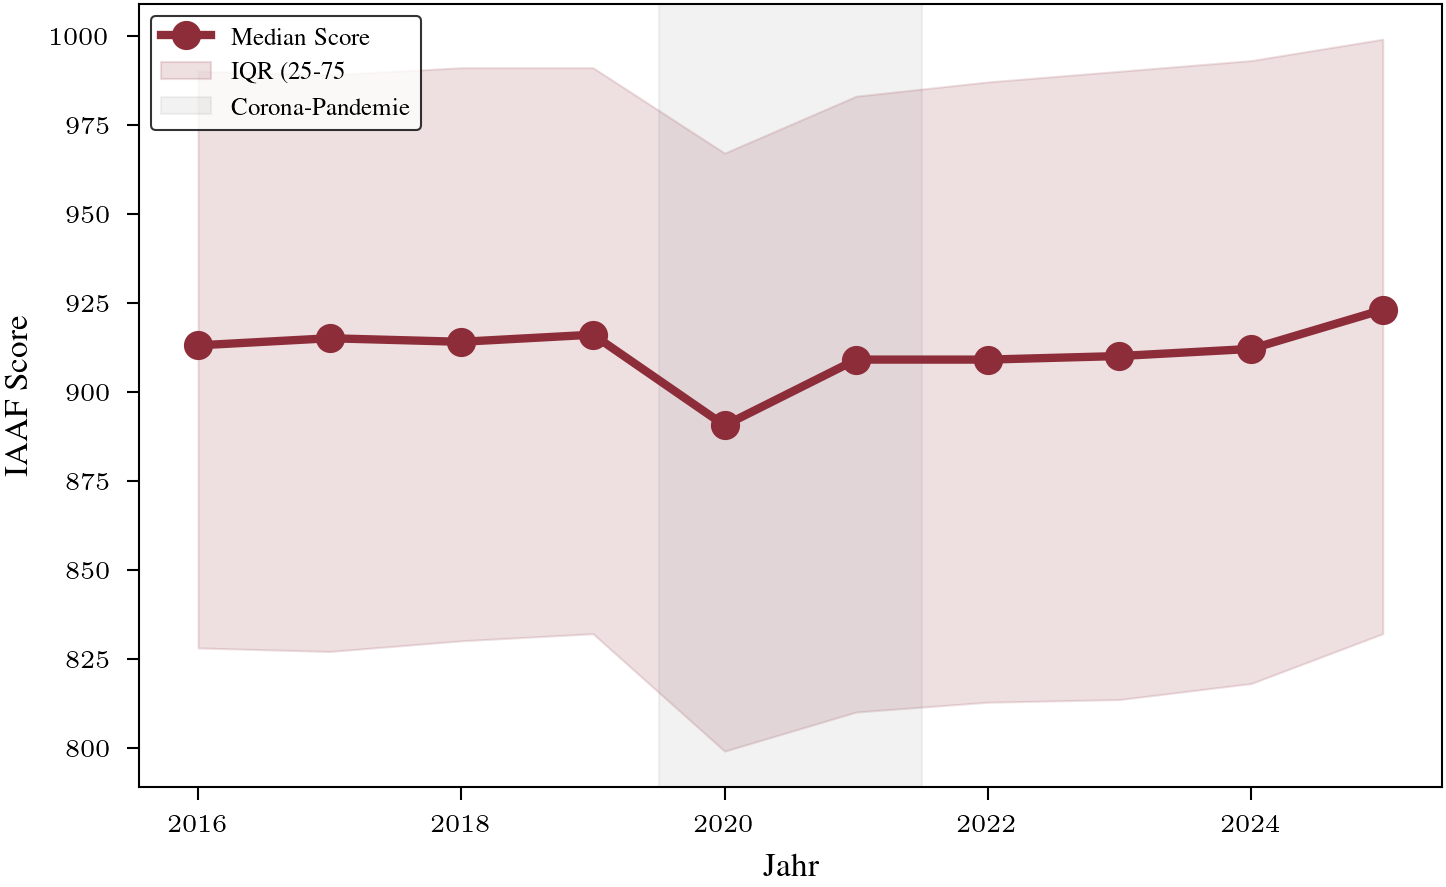

In [3]:
stats_per_year = df_recent.groupby('jahr')['iaaf_score'].agg(
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    count='count'
).reset_index()

with plt.rc_context(plt.increase_figsize(1.5)): 
    fig, ax = plt.subplots()
    
    ax.plot(stats_per_year['jahr'], stats_per_year['median'], 
            color=rgb.tue_red, linewidth=2, marker='o', label='Median Score')
    
    ax.fill_between(
        stats_per_year['jahr'], 
        stats_per_year['q25'], 
        stats_per_year['q75'], 
        color=rgb.tue_red, 
        alpha=0.15, 
        label='IQR (25-75%)'
    )

    ax.axvspan(2019.5, 2021.5, color='gray', alpha=0.1, label='Corona-Pandemie')

    # ax.set_title("Leistungsentwicklung (Median & Streuung)")
    ax.set_xlabel("Jahr")
    ax.set_ylabel("IAAF Score")
    ax.legend(loc='upper left')
    
    plt.show()

## 2. Aktivität: Balkendiagramm & Heatmap

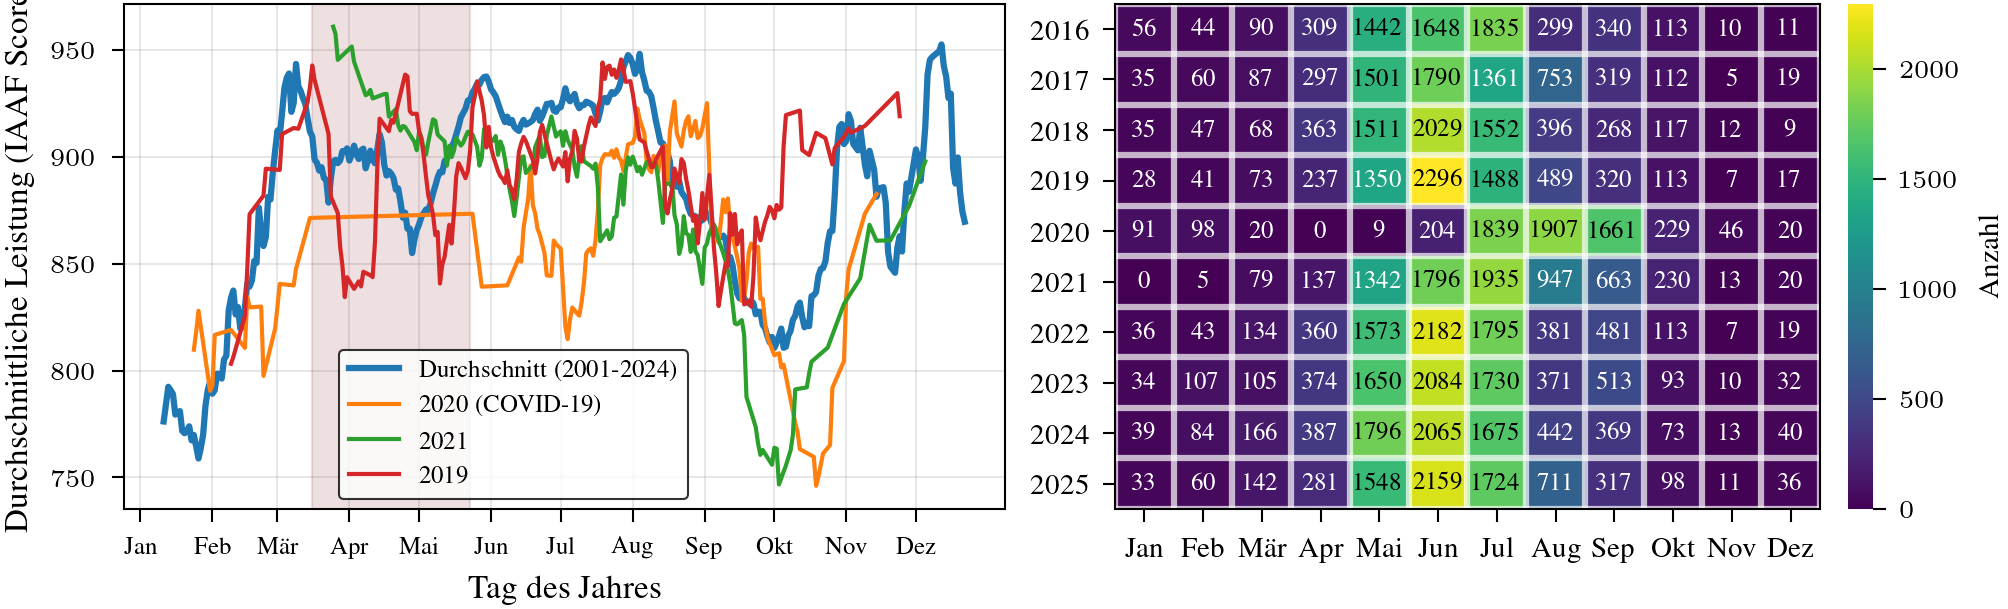

In [4]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

okabe_ito_colors = [
    "#E69F00", # Orange
    "#56B4E9", # Sky Blue
    "#009E73", # Bluish Green
    "#F0E442", # Yellow
    "#0072B2", # Blue
    "#D55E00", # Vermilion
    "#CC79A7", # Reddish Purple
    "#000000"  # Black
]
# plt.rcParams.update(plt.cycler.cycler(color=okabe_ito_colors))

tab10 = plt.get_cmap('tab10')
plt.rcParams.update(plt.cycler.cycler(color=tab10.colors))

activity_pivot = df_recent.pivot_table(
    index='jahr', 
    columns='month', 
    values='iaaf_score', 
    aggfunc='count',
    fill_value=0
    )

# Group by Day of Year across ALL years
global_stats = df_recent.groupby('day_of_year')['iaaf_score'].median()
global_smoothed = global_stats.rolling(window=14, center=True).mean()

lockdowns = [
    # Lockdown 1: Mid-March to Early May 2020
    (pd.to_datetime('2020-03-15').dayofyear, pd.to_datetime('2020-05-22').dayofyear),
    # Lockdown 2 ("Light" + "Bundesnotbremse"): Nov 2020 to ~June 2021
    # (pd.to_datetime('2020-11-02').dayofyear, 365)
]


with plt.rc_context(plt.bundles.icml2024(nrows=1, ncols=2, column="full")): 
    fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [5, 4]})

    # # Balkendiagramm
    # bars = ax1.barh(stats_per_year['jahr'], stats_per_year['count'], color=rgb.tue_gray, height=0.6)
    # ax1.set_title("Gesamtanzahl Leistungen")
    # ax1.set_xlabel("Anzahl")
    # ax1.set_yticks(stats_per_year['jahr'])
    # ax1.invert_yaxis()
    
    # for bar, year in zip(bars, stats_per_year['jahr']):
    #     if year == 2020:
    #         bar.set_color(rgb.tue_red)
    # Plot the global average
    ax1.plot(global_smoothed.index, global_smoothed, linewidth=1.5, label='Durchschnitt (2001-2024)', zorder=5)

    years = df_recent['jahr'].unique()
    for y in years:
        y_data = df_recent[df_recent['jahr'] == y].groupby('day_of_year')['iaaf_score'].median().rolling(window=14, center=True).mean()
        
        # Logic to highlight 2020
        if y == 2019:
            ax1.plot(y_data.index, y_data, alpha=1.0, linewidth=1.0, label='2019', zorder=10)
        elif y == 2021:
            ax1.plot(y_data.index, y_data, alpha=1.0, linewidth=1.0, label='2021', zorder=10)
        elif y == 2020:
            ax1.plot(y_data.index, y_data, alpha=1.0, linewidth=1.0, label='2020 (COVID-19)', zorder=10)
        # else:
        #     # ax1.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=((y - 2001) / (2024 - 2001)) / 2, linewidth=1)
        #     ax1.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=0.15, linewidth=1)

    

    for start, end in lockdowns:
        ax1.axvspan(start, end, color=rgb.tue_red, alpha=0.15)


    # plt.title('Der "Herzschlag" der Saison: Der Einbruch durch COVID-19 (2020)')
    ax1.set_xlabel('Tag des Jahres')
    ax1.set_ylabel('Durchschnittliche Leistung (IAAF Score)')
    ax1.legend(bbox_to_anchor=(0.23, 0.34))
    ax1.grid(True, alpha=0.3)


    # X-Axis formatting to Months
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
    ax1.set_xticks(month_starts)
    ax1.set_xticklabels(month_names)

    # Heatmap (Matplotlib imshow)
    heatmap_data = activity_pivot.values
    
    # SETUP DATEN FÜR TICKS
    years_idx = activity_pivot.index.values
    months_idx = activity_pivot.columns.values
    # month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

    # FARBSKALA WÄHLEN
    # 'viridis': Der Standard für Science (Dunkel -> Hell). Bester Kontrast.
    # Alternativen: 'Blues' (Klassisch), 'YlGnBu' (Mehrfarbig), 'magma' (Dunkel)
    cmap_name = 'viridis' 
    
    # Heatmap zeichnen
    im = ax2.imshow(heatmap_data, cmap=cmap_name, aspect='auto')

    # --- GRID & STYLING ---
    # Minor Ticks setzen das Gitter genau ZWISCHEN die Zellen
    ax2.set_xticks(np.arange(heatmap_data.shape[1] + 1) - 0.5, minor=True)
    ax2.set_yticks(np.arange(heatmap_data.shape[0] + 1) - 0.5, minor=True)
    
    # Gitter zeichnen (dünn und weiß, trennt die Zellen sauber)
    ax2.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
    ax2.tick_params(which="minor", bottom=False, left=False)

    # Achsen-Labels
    ax2.set_xticks(np.arange(len(months_idx)))
    ax2.set_xticklabels(month_names, fontsize=7)
    ax2.set_yticks(np.arange(len(years_idx)))
    ax2.set_yticklabels(years_idx, fontsize=7)
    
    # ax2.set_title("Saisonale Aktivität", fontsize=10)

    # --- TEXT ANNOTATIONEN ---
    # Logik für Textfarbe anpassen:
    # Bei 'viridis' ist der Hintergrund bei hohen Werten HELL (Gelb) -> Schwarzer Text
    # Bei niedrigen Werten DUNKEL (Lila) -> Weißer Text
    max_val = heatmap_data.max()
    threshold = max_val * 0.6 
    
    for i in range(len(years_idx)): 
        for j in range(len(months_idx)): 
            val = heatmap_data[i, j]
            
            # Nur anzeigen, wenn Wert vorhanden (> 0), reduziert visuelles Rauschen
            # if val > 0: 
            # Farbe basierend auf Hintergrundhelligkeit wählen
            if cmap_name == 'viridis':
                text_color = "black" if val > threshold else "white"
            elif cmap_name == 'Blues':
                # Bei Blues ist es umgekehrt: Hohe Werte sind dunkelblau
                text_color = "white" if val > threshold else "black"
            else:
                text_color = "white" # Fallback
            
            # Schriftgröße hier anpassen (fontsize=5 ist sehr klein aber passt oft)
            ax2.text(j, i, str(int(val)), ha="center", va="center", 
                        color=text_color, fontsize=6, fontweight='light')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False)
    cbar.set_label('Anzahl', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    plt.show()

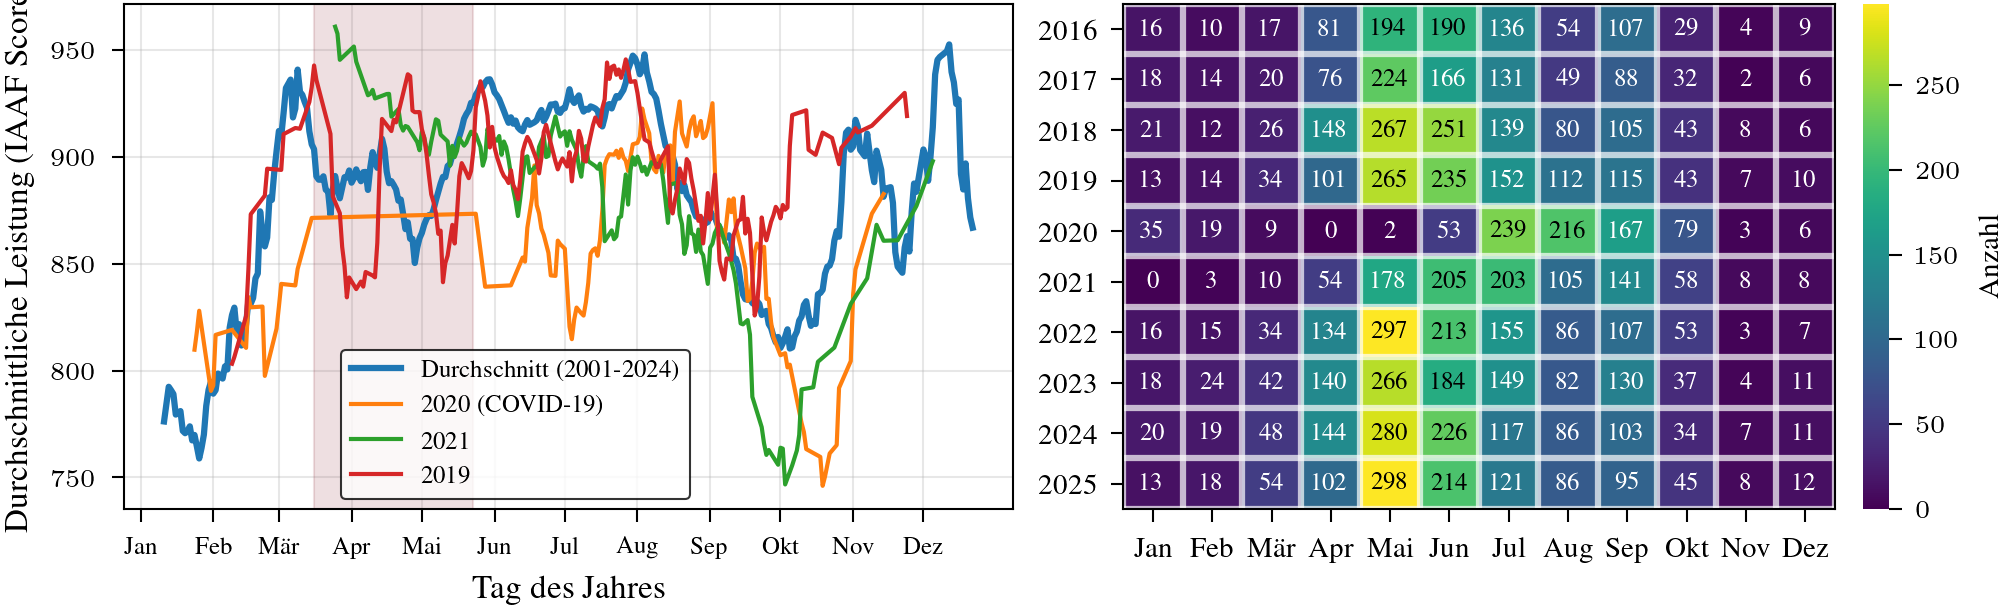

In [5]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

okabe_ito_colors = [
    "#E69F00", # Orange
    "#56B4E9", # Sky Blue
    "#009E73", # Bluish Green
    "#F0E442", # Yellow
    "#0072B2", # Blue
    "#D55E00", # Vermilion
    "#CC79A7", # Reddish Purple
    "#000000"  # Black
]
# plt.rcParams.update(plt.cycler.cycler(color=okabe_ito_colors))

tab10 = plt.get_cmap('tab10')
plt.rcParams.update(plt.cycler.cycler(color=tab10.colors))
df_germany = df_recent[~df_recent['ort'].str.contains(r'/[A-Z]{3}', regex=True)].copy()

df_germany['competition_id'] = df_germany['datum'].astype(str) + "_" + df_germany['ort'].astype(str) + "_" + df_germany['jahr'].astype(str)

# Calculate the pivot table for the heatmap (Competitions per month)
activity_pivot = df_germany.pivot_table(
    index='jahr', 
    columns='month', 
    values='competition_id', 
    aggfunc=lambda x: x.nunique(),
    fill_value=0
)

# Group by Day of Year across ALL years
global_stats = df_germany.groupby('day_of_year')['iaaf_score'].median()
global_smoothed = global_stats.rolling(window=14, center=True).mean()

lockdowns = [
    # Lockdown 1: Mid-March to Early May 2020
    (pd.to_datetime('2020-03-15').dayofyear, pd.to_datetime('2020-05-22').dayofyear),
    # Lockdown 2 ("Light" + "Bundesnotbremse"): Nov 2020 to ~June 2021
    # (pd.to_datetime('2020-11-02').dayofyear, 365)
]


with plt.rc_context(plt.bundles.icml2024(nrows=1, ncols=2, column="full")): 
    fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [5, 4]})

    # # Balkendiagramm
    # bars = ax1.barh(stats_per_year['jahr'], stats_per_year['count'], color=rgb.tue_gray, height=0.6)
    # ax1.set_title("Gesamtanzahl Leistungen")
    # ax1.set_xlabel("Anzahl")
    # ax1.set_yticks(stats_per_year['jahr'])
    # ax1.invert_yaxis()
    
    # for bar, year in zip(bars, stats_per_year['jahr']):
    #     if year == 2020:
    #         bar.set_color(rgb.tue_red)
    # Plot the global average
    ax1.plot(global_smoothed.index, global_smoothed, linewidth=1.5, label='Durchschnitt (2001-2024)', zorder=5)

    years = df_germany['jahr'].unique()
    for y in years:
        y_data = df_germany[df_germany['jahr'] == y].groupby('day_of_year')['iaaf_score'].median().rolling(window=14, center=True).mean()
        
        # Logic to highlight 2020
        if y == 2019:
            ax1.plot(y_data.index, y_data, alpha=1.0, linewidth=1.0, label='2019', zorder=10)
        elif y == 2021:
            ax1.plot(y_data.index, y_data, alpha=1.0, linewidth=1.0, label='2021', zorder=10)
        elif y == 2020:
            ax1.plot(y_data.index, y_data, alpha=1.0, linewidth=1.0, label='2020 (COVID-19)', zorder=10)
        # else:
        #     # ax1.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=((y - 2001) / (2024 - 2001)) / 2, linewidth=1)
        #     ax1.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=0.15, linewidth=1)

    

    for start, end in lockdowns:
        ax1.axvspan(start, end, color=rgb.tue_red, alpha=0.15)


    # plt.title('Der "Herzschlag" der Saison: Der Einbruch durch COVID-19 (2020)')
    ax1.set_xlabel('Tag des Jahres')
    ax1.set_ylabel('Durchschnittliche Leistung (IAAF Score)')
    ax1.legend(bbox_to_anchor=(0.23, 0.34))
    ax1.grid(True, alpha=0.3)


    # X-Axis formatting to Months
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
    ax1.set_xticks(month_starts)
    ax1.set_xticklabels(month_names)

    # Heatmap (Matplotlib imshow)
    heatmap_data = activity_pivot.values
    
    # SETUP DATEN FÜR TICKS
    years_idx = activity_pivot.index.values
    months_idx = activity_pivot.columns.values
    # month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

    # FARBSKALA WÄHLEN
    # 'viridis': Der Standard für Science (Dunkel -> Hell). Bester Kontrast.
    # Alternativen: 'Blues' (Klassisch), 'YlGnBu' (Mehrfarbig), 'magma' (Dunkel)
    cmap_name = 'viridis' 
    
    # Heatmap zeichnen
    im = ax2.imshow(heatmap_data, cmap=cmap_name, aspect='auto')

    # --- GRID & STYLING ---
    # Minor Ticks setzen das Gitter genau ZWISCHEN die Zellen
    ax2.set_xticks(np.arange(heatmap_data.shape[1] + 1) - 0.5, minor=True)
    ax2.set_yticks(np.arange(heatmap_data.shape[0] + 1) - 0.5, minor=True)
    
    # Gitter zeichnen (dünn und weiß, trennt die Zellen sauber)
    ax2.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
    ax2.tick_params(which="minor", bottom=False, left=False)

    # Achsen-Labels
    ax2.set_xticks(np.arange(len(months_idx)))
    ax2.set_xticklabels(month_names, fontsize=7)
    ax2.set_yticks(np.arange(len(years_idx)))
    ax2.set_yticklabels(years_idx, fontsize=7)
    
    # ax2.set_title("Saisonale Aktivität", fontsize=10)

    # --- TEXT ANNOTATIONEN ---
    # Logik für Textfarbe anpassen:
    # Bei 'viridis' ist der Hintergrund bei hohen Werten HELL (Gelb) -> Schwarzer Text
    # Bei niedrigen Werten DUNKEL (Lila) -> Weißer Text
    max_val = heatmap_data.max()
    threshold = max_val * 0.6 
    
    for i in range(len(years_idx)): 
        for j in range(len(months_idx)): 
            val = heatmap_data[i, j]
            
            # Nur anzeigen, wenn Wert vorhanden (> 0), reduziert visuelles Rauschen
            # if val > 0: 
            # Farbe basierend auf Hintergrundhelligkeit wählen
            if cmap_name == 'viridis':
                text_color = "black" if val > threshold else "white"
            elif cmap_name == 'Blues':
                # Bei Blues ist es umgekehrt: Hohe Werte sind dunkelblau
                text_color = "white" if val > threshold else "black"
            else:
                text_color = "white" # Fallback
            
            # Schriftgröße hier anpassen (fontsize=5 ist sehr klein aber passt oft)
            ax2.text(j, i, str(int(val)), ha="center", va="center", 
                        color=text_color, fontsize=6, fontweight='light')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False)
    cbar.set_label('Anzahl', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    plt.show()

In [6]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

# --- IMPROVEMENT 1: Custom Colormap to match your TUE Red ---
# Assuming rgb.tue_red is defined. If not, use "#A51E37" (approx hue)
# We create a map from White -> Light Red -> TUE Red
cmap_name = "white_to_tue"
# If you have rgb.tue_red object, use it, otherwise use hex string
tue_red_hex = getattr(rgb, 'tue_red', '#A51E37') 
colors = ["#ffffff", tue_red_hex] 
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)

# --- IMPROVEMENT 2: Plotting ---
# We use vmin=0 to ensure empty months are pure white
im = ax2.imshow(heatmap_data, cmap=custom_cmap, aspect='auto', vmin=0)

# --- IMPROVEMENT 3: The "Grid" Look ---
# Set minor ticks to draw the grid lines *between* the cells
ax2.set_xticks(np.arange(len(months) + 1) - 0.5, minor=True)
ax2.set_yticks(np.arange(len(years) + 1) - 0.5, minor=True)
ax2.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
ax2.tick_params(which="minor", bottom=False, left=False) # Hide the little tick marks

# --- IMPROVEMENT 4: Axis Labels ---
# Months: Use 3-letter codes or single letters to save space
month_labels = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
# If your 'months' variable is just numbers 1-12:
ax2.set_xticks(np.arange(len(months)))
ax2.set_xticklabels(month_labels, fontsize=8)

# Years: If there are many years, show every 2nd or 5th year to avoid crowding
ax2.set_yticks(np.arange(len(years)))
ax2.set_yticklabels(years, fontsize=8)

# --- IMPROVEMENT 5: Better Annotations ---
# Only show text if the number fits or is significant
threshold = heatmap_data.max() * 0.5
for i in range(len(years)): 
    for j in range(len(months)): 
        val = heatmap_data[i, j]
        # Skip zeros to reduce clutter (optional)
        if val == 0:
            continue
            
        color = "white" if val > threshold else "black"
        # Font size reduced to 6
        ax2.text(j, i, str(val), ha="center", va="center", color=color, fontsize=6)

ax2.set_title("Saisonale Aktivität", fontsize=10, pad=10)
ax2.set_xlabel("") # 'Monat' is obvious from labels
# Remove y-label "Jahr" if it's obvious, saves space

# Fix Colorbar
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False) # Cleaner look
cbar.set_label('Anzahl', fontsize=8)

plt.show()

NameError: name 'months' is not defined

## 3. Detail-Vergleich (Boxplots)

/var/folders/lf/d2nc392142b837mf8sypzlx00000gn/T/ipykernel_84029/1125801936.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=years_sorted, patch_artist=True,


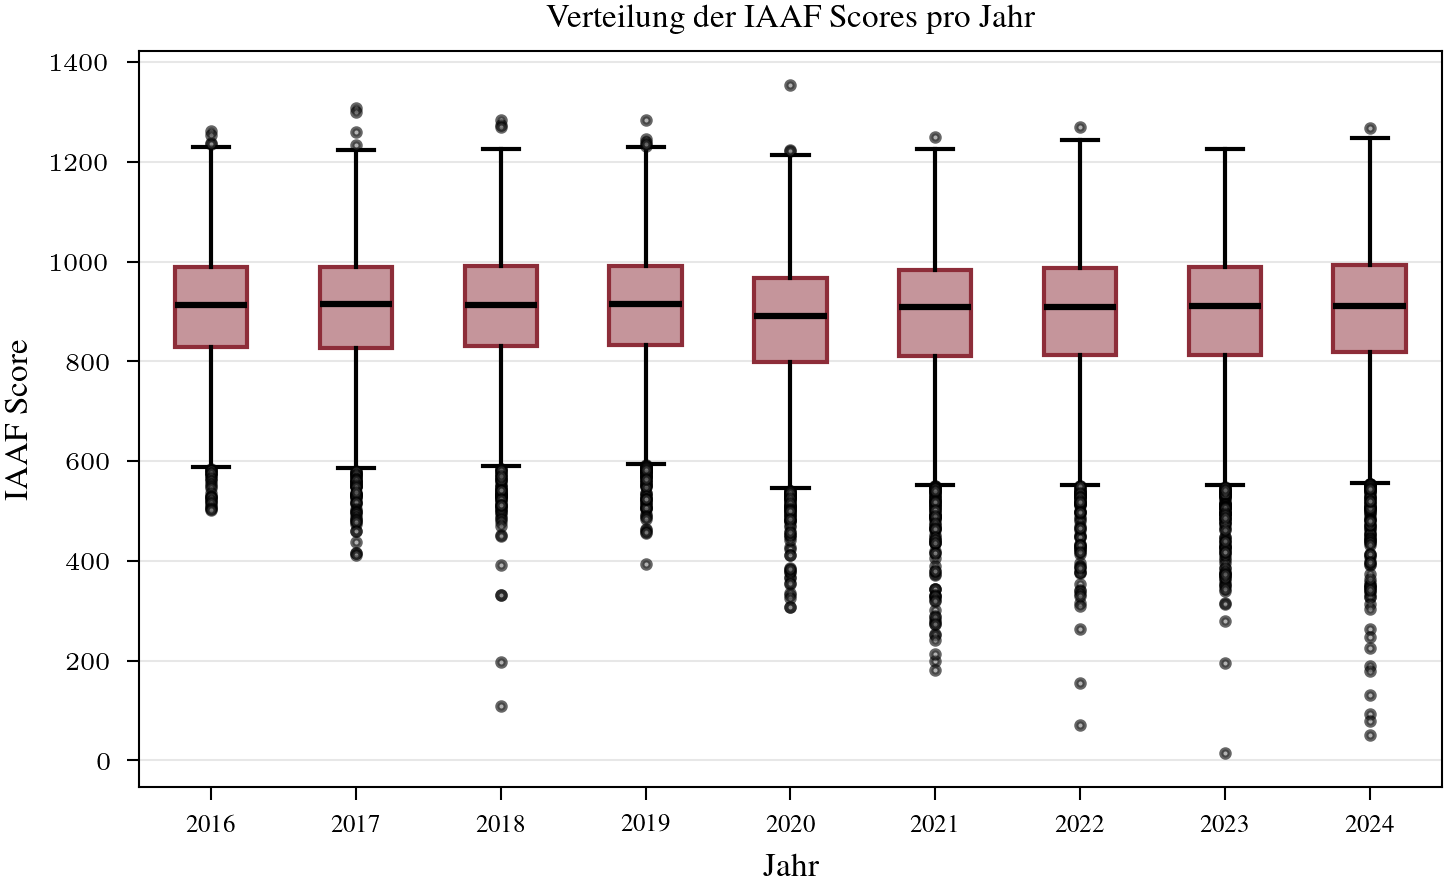

In [ ]:
years_sorted = sorted(df_recent['jahr'].unique())
data_to_plot = [df_recent[df_recent['jahr'] == y]['iaaf_score'].dropna().values for y in years_sorted]

with plt.rc_context(plt.increase_figsize(1.5)): 
    fig, ax = plt.subplots()
    
    bp = ax.boxplot(data_to_plot, labels=years_sorted, patch_artist=True, 
                    flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, linestyle='none', alpha=0.6))
    
    for box in bp['boxes']:
        box.set(color=rgb.tue_red, linewidth=1)
        box.set_facecolor((*rgb.tue_red, 0.5))

    for median in bp['medians']:
        median.set(color='black', linewidth=1.5)

    ax.set_title("Verteilung der IAAF Scores pro Jahr")
    ax.set_xlabel("Jahr")
    ax.set_ylabel("IAAF Score")
    ax.grid(axis='y', alpha=0.3)
    
    plt.show()

## 4. Statistischer Test (Mann-Whitney U)

In [ ]:
def compare_years(year1, year2):
    scores1 = df_recent[df_recent['jahr'] == year1]['iaaf_score'].dropna()
    scores2 = df_recent[df_recent['jahr'] == year2]['iaaf_score'].dropna()
    
    u_stat, p_val = stats.mannwhitneyu(scores1, scores2, alternative='greater')
    
    print(f"--- Vergleich {year1} vs. {year2} ---")
    print(f"Median {year1}: {scores1.median():.0f}")
    print(f"Median {year2}: {scores2.median():.0f}")
    print(f"P-Wert: {p_val:.5e}")
    if p_val < 0.05:
        print(f"Ergebnis: {year1} war SIGNIFIKANT besser als {year2}.")
    else:
        print("Ergebnis: Kein signifikanter Unterschied (oder Trend umgekehrt).")
    print("")

compare_years(2019, 2020)
compare_years(2020, 2021)
compare_years(2019, 2021)